# MÅL

Bruke reddits webapi til å:
- gjøre et søk på "elbiler"
- Hente alle artikler ("treff") fra det siste året
- Hente ut alle (nesten) kommentarer til innleggene
- putte det i pandas dataframe

evt:
- Gjøre sentimentanalyse med chatgpt api positiv/nøytral/negativ
- plotte utvikling (om noen)

In [195]:
import requests, json
import pandas as pd


In [266]:
with open("reddit_tokens.json", "r") as file:
    tokens = json.load(file)

access_token = tokens["access_token"]
refresh_token = tokens["refresh_token"]

client_id = "v2uZeXUHIszhF2K4hNOksQ"
client_secret = "2qamP2_KAEG7eNkXMwrJPhbb6jxzKw"

def refresh_tokens():
    global access_token, refresh_token
    refresh_url = "https://www.reddit.com/api/v1/access_token"
    payload = {"grant_type": "refresh_token", "refresh_token": refresh_token}
    headers = {"User-Agent": "python:undervisning_h25"}
    res = requests.post(refresh_url, auth=(client_id, client_secret), data=payload, headers=headers)
    res.raise_for_status()
    tokens = res.json()
    access_token = tokens["access_token"]
    refresh_token = tokens["refresh_token"]
    with open("reddit_tokens.json", "w") as file:
        json.dump(tokens,file)


def reddit_get(endpoint, params=None):
    base_url = "https://oauth.reddit.com"
    headers = {"Authorization": f"Bearer {access_token}",
              "User-Agent": "python:undervisning_h25"}
    res = requests.get(base_url+endpoint, headers=headers, params=params)
    res.raise_for_status()
    return res.json()

def reddit_search(q):
    params =  {
        "q": q,
        "sort": "top",
        "t": "year",
        "limit": 100
    }
    res_sider = []
    res = reddit_get("/search", params)
    res_sider.append(res)
    after = res["data"]["after"]
    
    while after:
        params = {
            "q": q,
            "sort": "top",
            "t": "year",
            "limit": 100,
            "after": after
        }
        res = reddit_get("/search", params)
        res_sider.append(res)
        after = res["data"]["after"]
    return res_sider



In [267]:
refresh_tokens()

In [268]:
params = {
    "q": "elbil",
    "sort": "top",
    "t": "year",
    "limit": 100
}

treff = reddit_search("elbil")



In [269]:
dfs = [ pd.json_normalize(dat, record_path=["data","children"]) for dat in treff]
df = pd.concat(dfs)
kolonner = ["kind", "data.subreddit", "data.selftext", 
            "data.author_fullname", "data.title", 
            "data.name", "data.id", "data.created", "data.url"]
df_search = df[kolonner]
df_search = df_search.set_index(pd.PeriodIndex(pd.to_datetime(df_search["data.created"],unit="s", utc=True), freq="D"))
df_search = df_search.sort_index()
df_search

,kind,data.subreddit,data.selftext,data.author_fullname,data.title,data.name,data.id,data.created,data.url
data.created,,,,,,,,,
2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...
2025-01-06,t3,DKbrevkasse,"Det er snevejr, Frost og regnvejr. Klokken er ...",t2_1c4dg6605p,Køre mine forældre i lufthavnen i snevejr,t3_1huqhmv,1huqhmv,1.736137e+09,https://www.reddit.com/r/DKbrevkasse/comments/...
2025-01-07,t3,elbilsverige,Hej!\n\nPendlar just nu ca 16 mil tor till job...,t2_7hi8870m,Ekonomiskt i min situation?,t3_1hveydk,1hveydk,1.736211e+09,https://www.reddit.com/r/elbilsverige/comments...
2025-01-08,t3,dkbiler,"Alle, en anden dag, endnu et spørgsmål om, hvi...",t2_4laog,Advice: Brugt stor elbil,t3_1hwknl0,1hwknl0,1.736344e+09,https://www.reddit.com/r/dkbiler/comments/1hwk...
2025-01-17,t3,dkfinance,Kære eksperter \n \nJeg er netop flyttet i h...,t2_4wikpnr8,Lease eller købe elbil?,t3_1i3bp7w,1i3bp7w,1.737102e+09,https://www.reddit.com/r/dkfinance/comments/1i...
...,...,...,...,...,...,...,...,...,...
2025-12-30,t3,dkbiler,"Hej dkbiler,\n\nHar akkurat fået min nye elbil...",t2_1d389k1hdr,Spørgsmål til parkeringsskilt,t3_1pzeot4,1pzeot4,1.767090e+09,https://i.redd.it/w53iygvnibag1.jpeg
2025-12-31,t3,dkbiler,Hvordan ser jeres ud ?\n,t2_lx8ghrud,Mit elforbrug i forhold til min nye elbil i 2025,t3_1q0l1t7,1q0l1t7,1.767209e+09,https://i.redd.it/jwgm2qfkalag1.jpeg
2026-01-02,t3,dkbiler,Min lokale Citroen forhandler kører nytårskamp...,t2_67s1m2q3,Nr. 2. elbil,t3_1q2a5ft,1q2a5ft,1.767387e+09,https://i.redd.it/atkb688n00bg1.jpeg


In [200]:
treff[0]["data"]["children"][0]["data"]["selftext"]
#print("Antall treff", len(treff["data"]["children"]))
#for post in treff["data"]["children"]:
#    print(post["data"]["selftext"])
#    print("------------------------------\n\n")

''

In [9]:
sinnatype = """'Etter å ha lest statistikken om hvor JÆVLIG mye Tesla vi nordmenn kjøper, kommer nok denne posten til å bli downvota til hælvete. Og jeg sier dette ekstra frustrert fordi foreldrene mine akkurat har kjøpt Tesla. Jeg vet de bare tenker på miljøet og økonomien. Men likevel, det føles bare så idiotisk. Salget i Europa har gått motsatt vei, men i Norge selges disse bilene som varmt hvetebrød... Vi i Norge liker å tro at vi er så moralsk overlegne når det kommer til amerikansk politikk. De aller fleste jeg snakker med synes DJT er en katastrofe. Egoisme, korrupsjon, ekkokamre, klimafornekting, splittelse. Likevel, når vi ser på hva som triller rundt på norske veier, er det Tesla overalt. Det er blitt nasjonalbilen? Og ja, jeg skjønner det er en elbil og at folk liker å tenke de gjør en miljøinnsats. Men på den andre siden, når du kjøper en Tesla, putter du penger rett i lomma på Elon Musk.\n\nOg Musk er grunnen til at DJT vant valget, og han flørter åpenlyst med høyreradikale miljøer, og spiller en enorm rolle i å normalisere holdninger vi i utgangspunktet hater i Norge. \nVi snakker om at vi ikke vil støtte krefter som undergraver demokratiet, retten på ferie, overtidsbetaling eller pusher ekstreme agendaer i Europa, men så ender vi likevel med å finansiere en av de største mikrofonene disse kreftene har. For meg er det akkurat det samme som å si at vi er anti-røyk men likevel investere massivt i Philip Morris.  \n\n'"""
sinnatype

"'Etter å ha lest statistikken om hvor JÆVLIG mye Tesla vi nordmenn kjøper, kommer nok denne posten til å bli downvota til hælvete. Og jeg sier dette ekstra frustrert fordi foreldrene mine akkurat har kjøpt Tesla. Jeg vet de bare tenker på miljøet og økonomien. Men likevel, det føles bare så idiotisk. Salget i Europa har gått motsatt vei, men i Norge selges disse bilene som varmt hvetebrød... Vi i Norge liker å tro at vi er så moralsk overlegne når det kommer til amerikansk politikk. De aller fleste jeg snakker med synes DJT er en katastrofe. Egoisme, korrupsjon, ekkokamre, klimafornekting, splittelse. Likevel, når vi ser på hva som triller rundt på norske veier, er det Tesla overalt. Det er blitt nasjonalbilen? Og ja, jeg skjønner det er en elbil og at folk liker å tenke de gjør en miljøinnsats. Men på den andre siden, når du kjøper en Tesla, putter du penger rett i lomma på Elon Musk.\n\nOg Musk er grunnen til at DJT vant valget, og han flørter åpenlyst med høyreradikale miljøer, og 

In [270]:

testid = df_search.iloc[0,-3]
url = df_search.iloc[0,-1]

comments_url = "/comments/article"
params = {"article": testid}

kommentar = reddit_get(comments_url, params)

with open("kommentartest.json", "w") as file:
    json.dump(kommentar,file)



In [202]:
kommentarer = kommentar[1]["data"]["children"].copy()
out = []
while len(kommentarer) > 0:
    kom = kommentarer.pop()
    if kom["kind"] == "Listing":
        kommentarer.extend(kom["data"]["children"])
    else:
        out.append(kom["data"]["body"])
        if isinstance(kom["data"]["replies"], dict):
            kommentarer.append(kom["data"]["replies"])



In [271]:
def get_comments(artikkel_id):
    comments_url = "/comments/article"
    params = {"article": artikkel_id}
    data = reddit_get(comments_url, params)
    kommentarer = data[1]["data"]["children"].copy()
    out = []
    while len(kommentarer) > 0:
        kom = kommentarer.pop()
        if kom["kind"] == "Listing":
            kommentarer.extend(kom["data"]["children"])
        elif kom["kind"] == "t1":
            out.append({"kommentar": kom["data"]["body"], "created": kom["data"]["created"]})
            if isinstance(kom["data"]["replies"], dict):
                kommentarer.append(kom["data"]["replies"])
    return out

testid = "1nqsvr8"
kommentarer = get_comments(testid)


In [272]:
%%time
df_search["kommentarer"] = df_search["data.id"].map(get_comments)
df_search.explode("kommentarer")

CPU times: user 3.35 s, sys: 194 ms, total: 3.54 s
Wall time: 2min 50s


,kind,data.subreddit,data.selftext,data.author_fullname,data.title,data.name,data.id,data.created,data.url,kommentarer
data.created,,,,,,,,,,
2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...,{'kommentar': 'Varför får du inte välja en tes...
2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...,{'kommentar': 'Hade hoppats på att det var pga...
2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...,"{'kommentar': 'Hört talas om Elon Musk?', 'cre..."
2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...,"{'kommentar': 'Sån cuck mentalitet av er 😂🤮', ..."
2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...,{'kommentar': 'Det är lätt att se varför du up...
...,...,...,...,...,...,...,...,...,...,...
2026-01-03,t3,dkfinance,Hej folkens!\n\nJeg plejer at lave indlæg omkr...,t2_njaylyg,Der er op til 2.500 kr. forskel på elregningen...,t3_1q381aw,1q381aw,1.767479e+09,https://i.redd.it/pmgj5zkck7bg1.jpeg,{'kommentar': 'Undskyld den forstår jeg nok ik...
2026-01-03,t3,dkfinance,Hej folkens!\n\nJeg plejer at lave indlæg omkr...,t2_njaylyg,Der er op til 2.500 kr. forskel på elregningen...,t3_1q381aw,1q381aw,1.767479e+09,https://i.redd.it/pmgj5zkck7bg1.jpeg,"{'kommentar': 'Ja, det er lidt komplekst. Hver..."
2026-01-03,t3,dkfinance,Hej folkens!\n\nJeg plejer at lave indlæg omkr...,t2_njaylyg,Der er op til 2.500 kr. forskel på elregningen...,t3_1q381aw,1q381aw,1.767479e+09,https://i.redd.it/pmgj5zkck7bg1.jpeg,{'kommentar': 'Alle mine homies flytter til Vi...


In [273]:
def split_kom_date(data):
    if isinstance(data, dict):
        dato = pd.to_datetime(data["created"],unit="s", utc=True)
        return pd.Series({"kommentar": data["kommentar"], "created": dato})
    else:
        return pd.Series({"kommentar": np.nan, "created": np.nan})

dft = df_search
dft["kommentarnummer"] = dft["kommentarer"].map(lambda x: list(range(len(x))))
dft  = dft.explode(["kommentarer", "kommentarnummer"])
 
#dft[["hehe", "haha"]] = dft["kommentarer"].apply(split_kom_date)
dft[["kommentar", "kommentardato"]] = dft["kommentarer"].apply(split_kom_date)
dft["kommentardato"] = pd.PeriodIndex(dft["kommentardato"], freq="D")
kolonner = list(dft.columns)
kolonner.remove("kommentarer")

dft = dft[kolonner]
dft = dft.rename(columns={"kommentar": "kommentarer"})
dft


,kind,data.subreddit,data.selftext,data.author_fullname,data.title,data.name,data.id,data.created,data.url,kommentarnummer,kommentarer,kommentardato
data.created,,,,,,,,,,,,
2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...,0,Varför får du inte välja en tesla för frugan??,2025-01-07
2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...,1,"Hade hoppats på att det var pga designen, men ...",2025-01-07
2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...,2,Hört talas om Elon Musk?,2025-01-07
2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...,3,Sån cuck mentalitet av er 😂🤮,2025-01-07
2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...,4,Det är lätt att se varför du uppskattar elon.,2025-01-07
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-03,t3,dkfinance,Hej folkens!\n\nJeg plejer at lave indlæg omkr...,t2_njaylyg,Der er op til 2.500 kr. forskel på elregningen...,t3_1q381aw,1q381aw,1.767479e+09,https://i.redd.it/pmgj5zkck7bg1.jpeg,94,"Undskyld den forstår jeg nok ikke 100%, de får...",2026-01-03
2026-01-03,t3,dkfinance,Hej folkens!\n\nJeg plejer at lave indlæg omkr...,t2_njaylyg,Der er op til 2.500 kr. forskel på elregningen...,t3_1q381aw,1q381aw,1.767479e+09,https://i.redd.it/pmgj5zkck7bg1.jpeg,95,"Ja, det er lidt komplekst. Hvert selskab har s...",2026-01-03
2026-01-03,t3,dkfinance,Hej folkens!\n\nJeg plejer at lave indlæg omkr...,t2_njaylyg,Der er op til 2.500 kr. forskel på elregningen...,t3_1q381aw,1q381aw,1.767479e+09,https://i.redd.it/pmgj5zkck7bg1.jpeg,96,Alle mine homies flytter til Videbæk nu,2026-01-03


In [274]:
df_search2 = dft
df_search2.index.name = "dato"
df = df_search2.copy()

In [275]:
df

,kind,data.subreddit,data.selftext,data.author_fullname,data.title,data.name,data.id,data.created,data.url,kommentarnummer,kommentarer,kommentardato
dato,,,,,,,,,,,,
2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...,0,Varför får du inte välja en tesla för frugan??,2025-01-07
2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...,1,"Hade hoppats på att det var pga designen, men ...",2025-01-07
2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...,2,Hört talas om Elon Musk?,2025-01-07
2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...,3,Sån cuck mentalitet av er 😂🤮,2025-01-07
2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...,4,Det är lätt att se varför du uppskattar elon.,2025-01-07
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-03,t3,dkfinance,Hej folkens!\n\nJeg plejer at lave indlæg omkr...,t2_njaylyg,Der er op til 2.500 kr. forskel på elregningen...,t3_1q381aw,1q381aw,1.767479e+09,https://i.redd.it/pmgj5zkck7bg1.jpeg,94,"Undskyld den forstår jeg nok ikke 100%, de får...",2026-01-03
2026-01-03,t3,dkfinance,Hej folkens!\n\nJeg plejer at lave indlæg omkr...,t2_njaylyg,Der er op til 2.500 kr. forskel på elregningen...,t3_1q381aw,1q381aw,1.767479e+09,https://i.redd.it/pmgj5zkck7bg1.jpeg,95,"Ja, det er lidt komplekst. Hvert selskab har s...",2026-01-03
2026-01-03,t3,dkfinance,Hej folkens!\n\nJeg plejer at lave indlæg omkr...,t2_njaylyg,Der er op til 2.500 kr. forskel på elregningen...,t3_1q381aw,1q381aw,1.767479e+09,https://i.redd.it/pmgj5zkck7bg1.jpeg,96,Alle mine homies flytter til Videbæk nu,2026-01-03


In [149]:
from typing import List, Literal, Optional
from pydantic import BaseModel, Field
from openai import OpenAI
import os

# 1. The inner-most model
class User(BaseModel):
    name: str = Field(description="The full name of the person")
    role: str = Field(description="Their job title or department")

# 2. The middle-layer model
class Task(BaseModel):
    title: str
    priority: Literal["high", "medium", "low"]
    assignee: User  # Nesting the User model here

# 3. The root model
class Project(BaseModel):
    project_name: str
    deadline: str
    tasks: List[Task] # A list of nested Task objects
    budget_approved: bool

Project.model_json_schema()

{'$defs': {'Task': {'properties': {'title': {'title': 'Title',
     'type': 'string'},
    'priority': {'enum': ['high', 'medium', 'low'],
     'title': 'Priority',
     'type': 'string'},
    'assignee': {'$ref': '#/$defs/User'}},
   'required': ['title', 'priority', 'assignee'],
   'title': 'Task',
   'type': 'object'},
  'User': {'properties': {'name': {'description': 'The full name of the person',
     'title': 'Name',
     'type': 'string'},
    'role': {'description': 'Their job title or department',
     'title': 'Role',
     'type': 'string'}},
   'required': ['name', 'role'],
   'title': 'User',
   'type': 'object'}},
 'properties': {'project_name': {'title': 'Project Name', 'type': 'string'},
  'deadline': {'title': 'Deadline', 'type': 'string'},
  'tasks': {'items': {'$ref': '#/$defs/Task'},
   'title': 'Tasks',
   'type': 'array'},
  'budget_approved': {'title': 'Budget Approved', 'type': 'boolean'}},
 'required': ['project_name', 'deadline', 'tasks', 'budget_approved'],
 '

In [276]:
from pydantic import BaseModel, Field
from openai import OpenAI
import os, time


class analyse_kommentar(BaseModel):
    kommentarnummer: int = Field("Korresponderende kommentarnummer")
    analyse: int = Field("Sentimentanalyse av kommentar #kommentarnummer# (0 nøytral, -1 negativ, +1 positiv")

class sentimentanalyse(BaseModel):
    post: int = Field("sentimentanalyse av hovedartikkel: 0 nøytral/ikke-relevant, -1 negativ, +1 positiv")
    kommentar: list[analyse_kommentar]


client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

def analyser(komm):
    time.sleep(.5)
    
    completion = client.beta.chat.completions.parse(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "Du er ekspert på sentimentanalyse av holdninger rundt elbiler og det grønne skiftet og ser på lister med innlegg og kommentarer fra reddit på norsk, dansk og svensk og vurderer om de er positiv, negativ eller nøytral til elbiler"},
            {"role": "user", "content": f"Under er en redditpost sammen med kommentarfeltet i en liste av strenger - du skal vurdere om kommentarene eller person som skriver de er positiv, negativ eller nøytral/ikke-relevant til elbiler. 1 for positiv, -1 for negativ og 0 for nøytral, eller om artikkel/kommentar ikke er relevant\n{komm}"}
        ],
        response_format=sentimentanalyse
    )
    return completion


In [277]:

log = []

def analyser_post(df_post):
    
    dat = {"post": df_post["data.selftext"].iloc[0]}
    dat.update({str(i): kommentar for i,kommentar in zip(df_post["kommentarnummer"],df_post["kommentarer"])})

    resp = analyser(dat)
    data_resp = resp.choices[0].message.parsed.model_dump()
    log.append(data_resp)
    if data_resp["kommentar"]:
        ny_df = pd.json_normalize(data_resp, "kommentar", meta="post")
    else:
        ny_df = pd.Series({"post": data_resp["post"], "kommentarnummer": np.nan, "analyse": np.nan} ).to_frame().T
    return ny_df


#test = df.query("`data.title`.str.contains('Låne i frivæ')")
#test_dat = list(test["data.selftext"].unique())
#test_dat.extend(list(test["kommentarer"]))

#test_dat = {"post": test["data.selftext"].iloc[0]}
#kommentarer = {f"{i}": kommentar for i,kommentar in enumerate(list(test["kommentarer"]))}

#test_dat.update(kommentarer)

#resp = analyser(test_dat)

In [40]:
data = resp.choices[0].message.parsed.model_dump()

NameError: name 'resp' is not defined

In [39]:
d = pd.json_normalize(data, "kommentar", meta="post").drop(columns="nummer")
tmp = pd.concat([d.set_index(test.index), test], axis=1)




NameError: name 'data' is not defined

In [44]:
df_test = df.query("`data.selftext`.str.contains('Jeg tog turen')")
test_res = df_test.groupby(by="data.id").apply(analyser_post, include_groups=False)


In [278]:
%%time
big = df.groupby(by="data.id").apply(analyser_post, include_groups=False)
big.to_csv("sentimentanalyse2.csv")

CPU times: user 4.68 s, sys: 0 ns, total: 4.68 s
Wall time: 57min 1s


In [279]:
big  = big.astype({"kommentarnummer": "Int64"})

In [280]:
df_done = dft.reset_index().merge(big, on=["data.id", "kommentarnummer"])
#dft.reset_index().merge(big.reset_index(), on="data.id").query("`data.id`== '1pymmgu'")
df_done

,dato,kind,data.subreddit,data.selftext,data.author_fullname,data.title,data.name,data.id,data.created,data.url,kommentarnummer,kommentarer,kommentardato,analyse,post
0,2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...,0,Varför får du inte välja en tesla för frugan??,2025-01-07,0.0,0
1,2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...,1,"Hade hoppats på att det var pga designen, men ...",2025-01-07,-1.0,0
2,2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...,2,Hört talas om Elon Musk?,2025-01-07,0.0,0
3,2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...,3,Sån cuck mentalitet av er 😂🤮,2025-01-07,-1.0,0
4,2025-01-06,t3,elbilsverige,Ska köpa bil snart och såg att man kan köpa en...,t2_15a1xw4rhc,Polestar 2 vs ID.4 begagnad,t3_1hvdi6l,1hvdi6l,1.736207e+09,https://www.reddit.com/r/elbilsverige/comments...,4,Det är lätt att se varför du uppskattar elon.,2025-01-07,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14763,2026-01-03,t3,dkfinance,Hej folkens!\n\nJeg plejer at lave indlæg omkr...,t2_njaylyg,Der er op til 2.500 kr. forskel på elregningen...,t3_1q381aw,1q381aw,1.767479e+09,https://i.redd.it/pmgj5zkck7bg1.jpeg,94,"Undskyld den forstår jeg nok ikke 100%, de får...",2026-01-03,0.0,0
14764,2026-01-03,t3,dkfinance,Hej folkens!\n\nJeg plejer at lave indlæg omkr...,t2_njaylyg,Der er op til 2.500 kr. forskel på elregningen...,t3_1q381aw,1q381aw,1.767479e+09,https://i.redd.it/pmgj5zkck7bg1.jpeg,95,"Ja, det er lidt komplekst. Hvert selskab har s...",2026-01-03,0.0,0
14765,2026-01-03,t3,dkfinance,Hej folkens!\n\nJeg plejer at lave indlæg omkr...,t2_njaylyg,Der er op til 2.500 kr. forskel på elregningen...,t3_1q381aw,1q381aw,1.767479e+09,https://i.redd.it/pmgj5zkck7bg1.jpeg,96,Alle mine homies flytter til Videbæk nu,2026-01-03,0.0,0
14766,2026-01-03,t3,dkfinance,Hej folkens!\n\nJeg plejer at lave indlæg omkr...,t2_njaylyg,Der er op til 2.500 kr. forskel på elregningen...,t3_1q381aw,1q381aw,1.767479e+09,https://i.redd.it/pmgj5zkck7bg1.jpeg,97,Det ba’ en landsby midt inde i Jylland…,2026-01-04,0.0,0


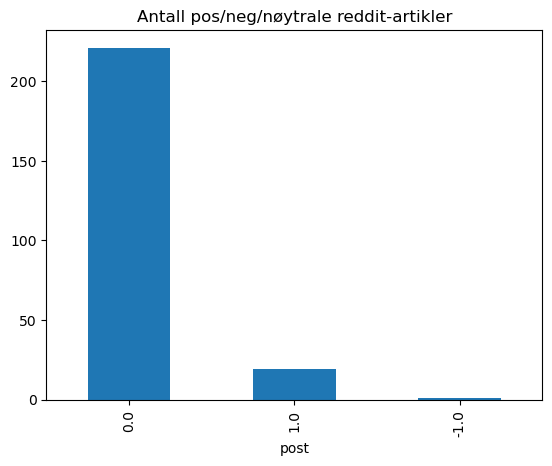

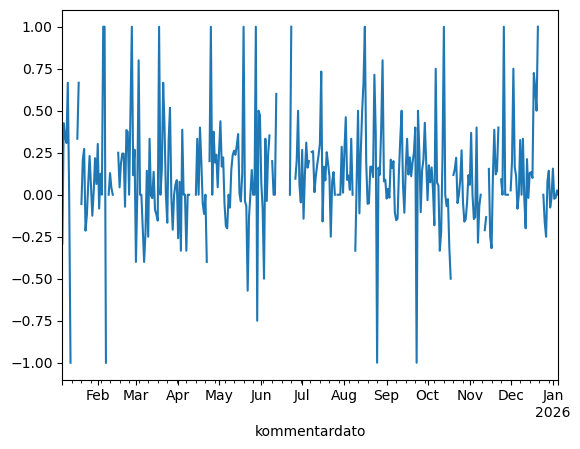

In [284]:
import matplotlib.pyplot as plt
df_posts = df_done.groupby(by=["data.id", "dato"])["post"].mean().to_frame().reset_index()
df_posts["post"].value_counts().plot.bar()
plt.title("Antall pos/neg/nøytrale reddit-artikler")
plt.show()

df_done.index = df_done.set_index("kommentardato").index.to_timestamp()
df_done.resample("D")["analyse"].mean().plot()
plt.show()

In [37]:
edgecase = {'post': 0, 'kommentar': []}
import numpy as np
pd.Series({"post": int(edgecase["post"]), "analyse": np.nan} ).to_frame().T

,post,analyse
0,0.0,NaN


In [25]:
regular =  {'post': 1,
  'kommentar': [{'nummer': 0, 'analyse': -1},
   {'nummer': 1, 'analyse': 0},
   {'nummer': 2, 'analyse': 0},
   {'nummer': 3, 'analyse': 0},
   {'nummer': 4, 'analyse': 0},
   {'nummer': 5, 'analyse': 1},
   {'nummer': 6, 'analyse': 1},
   {'nummer': 7, 'analyse': 1},
   {'nummer': 8, 'analyse': 1},
   {'nummer': 9, 'analyse': 1},
   {'nummer': 10, 'analyse': 1},
   {'nummer': 11, 'analyse': 1},
   {'nummer': 12, 'analyse': 1},
   {'nummer': 13, 'analyse': 1},
   {'nummer': 14, 'analyse': 1},
   {'nummer': 15, 'analyse': 1},
   {'nummer': 16, 'analyse': 1},
   {'nummer': 17, 'analyse': 1},
   {'nummer': 18, 'analyse': 1},
   {'nummer': 19, 'analyse': 1},
   {'nummer': 20, 'analyse': 1}]}
pd.json_normalize(regular, "kommentar", meta="post").drop(columns="nummer")

,analyse,post
0,-1,1
1,0,1
2,0,1
3,0,1
4,0,1
5,1,1
6,1,1
7,1,1
8,1,1
9,1,1


In [45]:
test_res

analyse post
data.id                 
1phc5l0 0         1    0
        1        -1    0
        2         1    0
        3         1    0
        4         1    0
        5         1    0
        6        -1    0
        7        -1    0
        8         1    0
        9        -1    0
        10        1    0
        11        1    0
        12        1    0
        13        1    0
        14        1    0
        15        0    0
        16        0    0
        17        1    0
        18        1    0
        19       -1    0
        20        1    0
        21        0    0
        22        0    0
        23        0    0
        24       -1    0
        25        1    0
        26        0    0
        27       -1    0
        28        1    0
        29        1    0
        30        1    0
        31        1    0
        32        0    0
        33        1    0
        34        0    0
        35        1    0
        36        1    0
        37        1    0
        38       -1    0
        39        1    0
        40        1    0
        41        0    0
        42        0    0
        43        1    0
        44        1    0
        45       -1    0
        46        1    0
        47        1    0
        48       -1    0
        49        0    0
        50        0    0
        51        0    0
        52        1    0
        53        0    0
        54        0    0
        55        0    0
        56        0    0
        57        1    0
        58        1    0
        59        0    0